In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sns.set_theme(style="whitegrid")

In [123]:
edges_df = pd.read_csv('data/edges.csv')
nodes_df = pd.read_csv('data/nodes.csv')

print(nodes_df.isnull().sum())
print(edges_df.isnull().sum())

print(nodes_df['node_type'].value_counts())
print(edges_df['type'].value_counts())

id           0
node_type    0
dtype: int64
source         0
target         0
type           0
weight    201629
dtype: int64
node_type
user    100714
game     41410
Name: count, dtype: int64
type
game      798371
friend    201629
Name: count, dtype: int64


Liczba wszystkich odkrytych użytkowników: 100714
Liczba użytkowników z publiczną biblioteką: 511
Liczba użytkowników bez gier (prywatnych): 100203
Procent 'pustych' profili: 99.49%



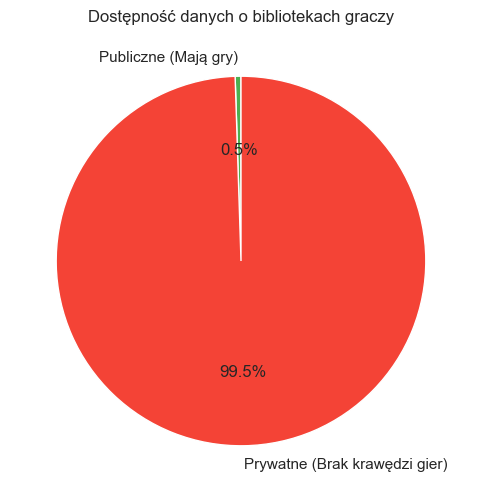

In [124]:
# Wyciągamy unikalne ID do zbiorów (sets) dla maksymalnej wydajności
all_users = set(nodes_df[nodes_df['node_type'] == 'user']['id'].astype(str))
users_with_games = set(edges_df[edges_df['type'] == 'game']['source'].astype(str))

users_without_games = all_users - users_with_games
empty_ratio = len(users_without_games) / len(all_users)

print(f"Liczba wszystkich odkrytych użytkowników: {len(all_users)}")
print(f"Liczba użytkowników z publiczną biblioteką: {len(users_with_games)}")
print(f"Liczba użytkowników bez gier (prywatnych): {len(users_without_games)}")
print(f"Procent 'pustych' profili: {empty_ratio * 100:.2f}%\n")

# Szybka wizualizacja luki w danych
plt.figure(figsize=(6, 6))
plt.pie([len(users_with_games), len(users_without_games)], 
        labels=['Publiczne (Mają gry)', 'Prywatne (Brak krawędzi gier)'], 
        autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
plt.title('Dostępność danych o bibliotekach graczy')
plt.show()

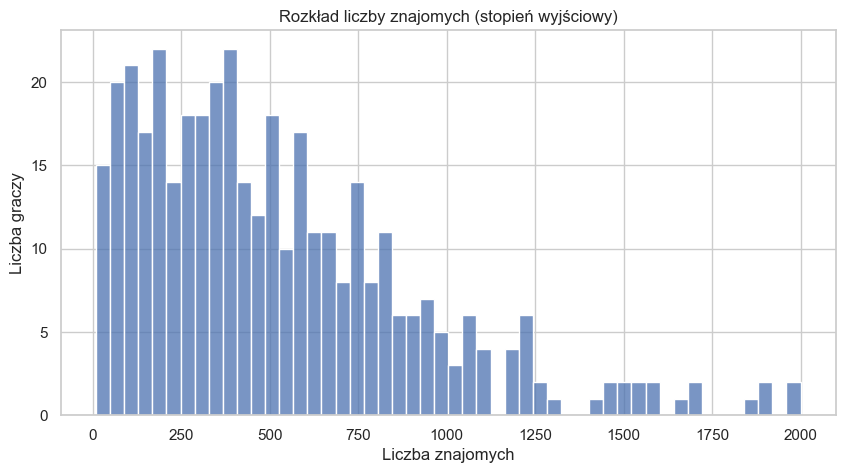

count     388.000000
mean      519.662371
std       395.250925
min         9.000000
25%       218.750000
50%       418.000000
75%       733.500000
max      2000.000000
Name: count, dtype: float64


In [125]:
friends_edges = edges_df[edges_df['type'] == 'friend']

friends_count = friends_edges['source'].value_counts()

plt.figure(figsize=(10, 5))
sns.histplot(friends_count, bins=50)
plt.title('Rozkład liczby znajomych (stopień wyjściowy)')
plt.xlabel('Liczba znajomych')
plt.ylabel('Liczba graczy')
plt.show()

print(friends_count.describe())

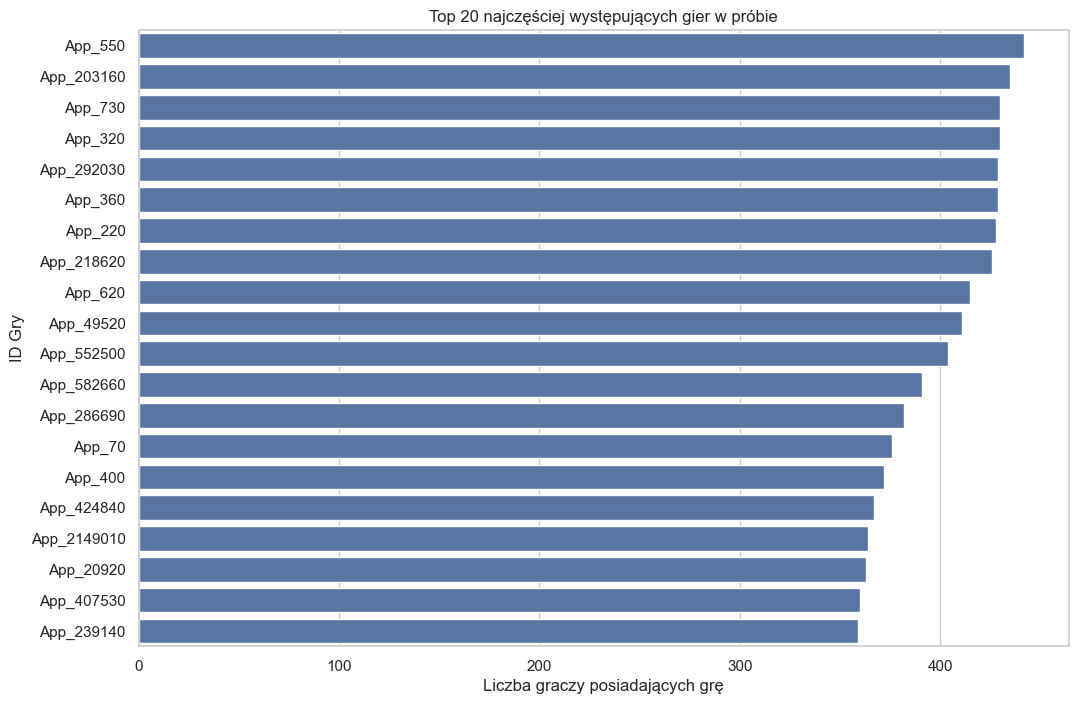

In [126]:
games_edges = edges_df[edges_df['type'] == 'game']

top_games = games_edges['target'].value_counts().head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_games.values, y=top_games.index)
plt.title('Top 20 najczęściej występujących gier w próbie')
plt.xlabel('Liczba graczy posiadających grę')
plt.ylabel('ID Gry')
plt.show()

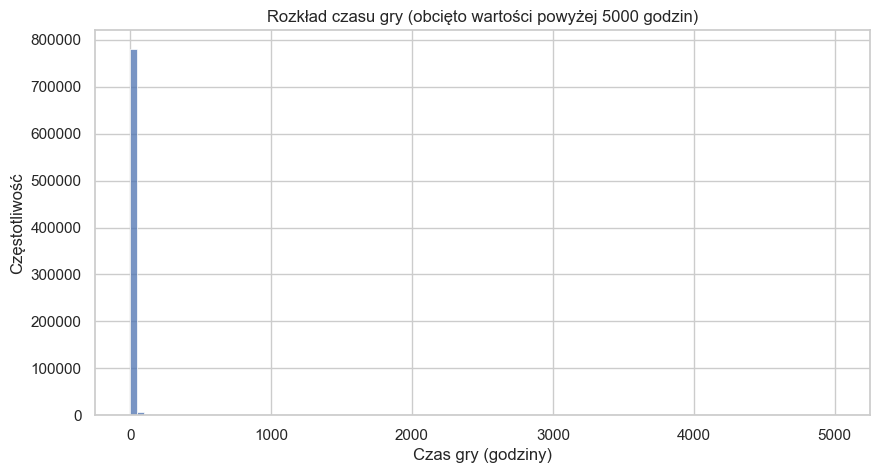

In [127]:
games_edges_clean = games_edges.copy()
games_edges_clean['weight'] = pd.to_numeric(games_edges_clean['weight'], errors='coerce')

playtime_hours = games_edges_clean['weight'] / 60

plt.figure(figsize=(10, 5))
sns.histplot(playtime_hours[playtime_hours < 5000], bins=100)
plt.title('Rozkład czasu gry (obcięto wartości powyżej 5000 godzin)')
plt.xlabel('Czas gry (godziny)')
plt.ylabel('Częstotliwość')
plt.show()

In [128]:
G = nx.from_pandas_edgelist(friends_edges, 'source', 'target')

print(nx.number_of_nodes(G))
print(nx.number_of_edges(G))

components = list(nx.connected_components(G))
print(len(components))

largest_cc = max(components, key=len)
print(len(largest_cc) / nx.number_of_nodes(G))

101102
201629
1
1.0


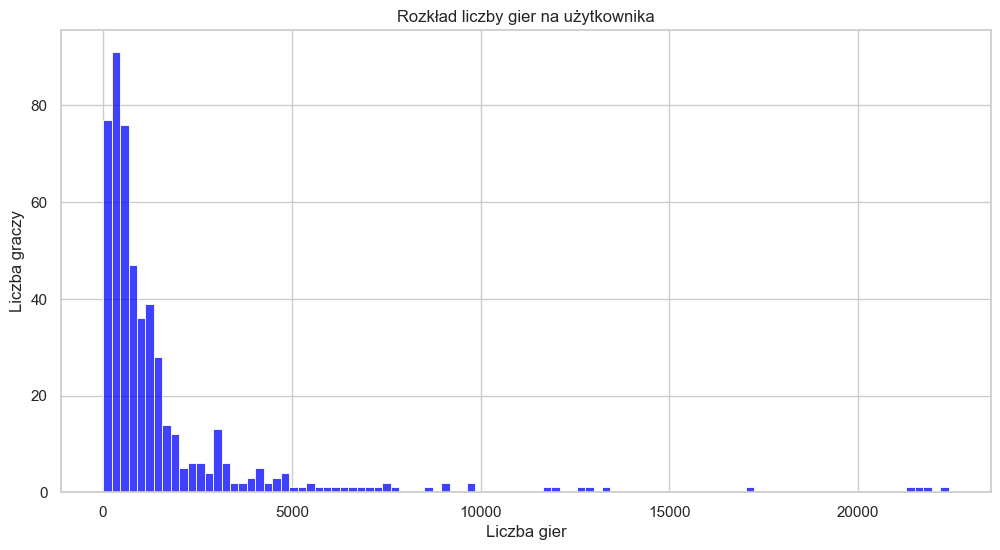

count      511.000000
mean      1562.369863
std       2727.724795
min          2.000000
25%        332.500000
50%        732.000000
75%       1443.500000
max      22398.000000
Name: target, dtype: float64


In [129]:
user_games_edges = edges_df[edges_df['type'] == 'game']
games_per_user = user_games_edges.groupby('source')['target'].count()

plt.figure(figsize=(12, 6))
sns.histplot(games_per_user, bins=100, color='blue')
plt.title('Rozkład liczby gier na użytkownika')
plt.xlabel('Liczba gier')
plt.ylabel('Liczba graczy')
plt.show()

print(games_per_user.describe())

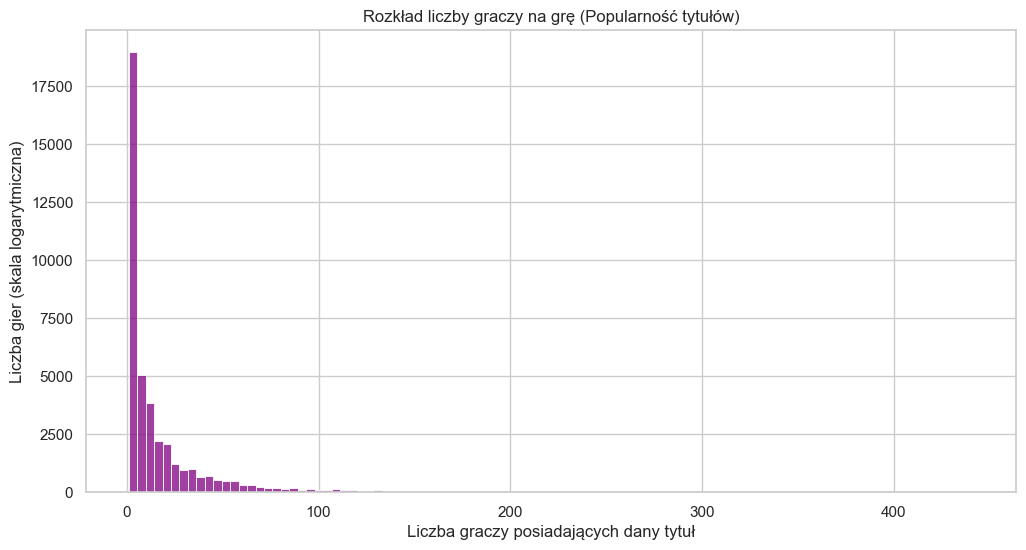

count    41410.000000
mean        19.279667
std         34.471385
min          1.000000
25%          2.000000
50%          7.000000
75%         21.000000
max        442.000000
Name: source, dtype: float64


In [132]:
games_edges = edges_df[edges_df['type'] == 'game']
players_per_game = games_edges.groupby('target')['source'].count()

plt.figure(figsize=(12, 6))
sns.histplot(players_per_game, bins=100, color='purple')
plt.title('Rozkład liczby graczy na grę (Popularność tytułów)')
plt.xlabel('Liczba graczy posiadających dany tytuł')
plt.ylabel('Liczba gier (skala logarytmiczna)')
plt.show()

print(players_per_game.describe())